# Notebook 02 — Parsing and Cleaning

Each cached match is one json file with ten participants. This notebook turns that
raw json into a tidy **player match table**, one row per engaged player per match,
applies the cleaning rules, and extracts the behavioral and motivation signals used
later. The result, `player_match.csv`, feeds notebook 03.

## Cleaning and extraction rules

- Keep ranked solo only, `queueId == 420`. Drop remakes (`gameEndedInEarlySurrender`)
  and games under five minutes.
- One row per **engaged** player who appears in a match.
- Role from `teamPosition`. CS as minions plus neutral monsters. KDA as
  `(kills + assists) / deaths`.
- Motivation signals: time spent dead, whether the player had the most deaths on the
  team and in the whole game, kill participation, team damage share, multikills,
  a frustration ping count, surrender losses, and first blood.

In [1]:
%matplotlib inline
import json
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("..")/"data"; RAW = DATA/"raw_matches"; OUT = DATA/"player_match.csv"
RANKED_SOLO_QUEUE = 420; MIN_DURATION_SEC = 300
NAVY, GOLD, RED = "#1A3A5C", "#C9A14A", "#C62828"
pd.set_option("display.max_columns", None)

In [2]:
def patch_of(gv):
    if not gv: return None
    p = gv.split("."); return f"{p[0]}.{p[1]}" if len(p) >= 2 else gv

def duration_seconds(info):
    d = info.get("gameDuration", 0); return int(d/1000 if d > 60000 else d)

def extract_rows(match, engaged):
    info = match.get("info", {})
    if info.get("queueId") != RANKED_SOLO_QUEUE: return []
    duration = duration_seconds(info); start_ts = info.get("gameStartTimestamp")
    if not start_ts: return []
    start_dt = datetime.fromtimestamp(start_ts/1000, tz=timezone.utc)
    patch = patch_of(info.get("gameVersion")); match_id = match.get("metadata", {}).get("matchId")
    minutes = duration/60 if duration else 0
    parts = info.get("participants", [])
    game_max_deaths = max((q.get("deaths", 0) for q in parts), default=0)
    team_max = {}
    for q in parts:
        t = q.get("teamId"); team_max[t] = max(team_max.get(t, 0), q.get("deaths", 0))
    rows = []
    for p in parts:
        puuid = p.get("puuid")
        if puuid not in engaged: continue
        if p.get("gameEndedInEarlySurrender") or duration < MIN_DURATION_SEC: continue
        k, dth, a = p.get("kills", 0), p.get("deaths", 0), p.get("assists", 0)
        kda = (k+a)/dth if dth > 0 else (k+a)
        cs = p.get("totalMinionsKilled", 0) + p.get("neutralMinionsKilled", 0)
        ch = p.get("challenges", {}); tid = p.get("teamId")
        fp = (p.get("assistMePings",0)+p.get("enemyMissingPings",0)+p.get("getBackPings",0)
              +p.get("retreatPings",0)+p.get("dangerPings",0))
        mk = p.get("doubleKills",0)+p.get("tripleKills",0)+p.get("quadraKills",0)+p.get("pentaKills",0)
        rows.append({"puuid":puuid,"match_id":match_id,"tier":engaged[puuid]["tier"],
            "churned":engaged[puuid]["churned"],"game_start":start_dt.isoformat(),
            "game_date":start_dt.date().isoformat(),"game_hour_utc":start_dt.hour,"patch":patch,
            "duration_sec":duration,"champion":p.get("championName"),
            "position":p.get("teamPosition") or "UNKNOWN","win":int(bool(p.get("win"))),
            "surrender":int(bool(p.get("gameEndedInSurrender"))),"kills":k,"deaths":dth,"assists":a,
            "kda":round(kda,3),"cs":cs,"cs_per_min":round(cs/minutes,2) if minutes else 0,
            "gold":p.get("goldEarned",0),"gold_per_min":round(p.get("goldEarned",0)/minutes,2) if minutes else 0,
            "damage_to_champs":p.get("totalDamageDealtToChampions",0),"damage_taken":p.get("totalDamageTaken",0),
            "vision_score":p.get("visionScore",0),"champ_level":p.get("champLevel",0),
            "account_level":p.get("summonerLevel",0),"time_dead_sec":p.get("totalTimeSpentDead",0),
            "team_death_leader":int(dth==team_max.get(tid,0)),"game_death_leader":int(dth==game_max_deaths),
            "kill_participation":round(ch.get("killParticipation") or 0,4),
            "team_damage_share":round(ch.get("teamDamagePercentage") or 0,4),
            "solo_kills":ch.get("soloKills") or 0,"multikills":mk,"frustration_pings":fp,
            "first_blood":int(bool(p.get("firstBloodKill")))})
    return rows

def load_engaged():
    rows = json.load(open(DATA/"population.json", encoding="utf-8"))
    return {r["puuid"]:{"tier":r["tier"],"churned":r["churned"]} for r in rows if r.get("engaged")}

def parse_all(engaged):
    out=[]
    for fp in sorted(RAW.glob("*.json")): out += extract_rows(json.load(open(fp,encoding="utf-8")), engaged)
    return pd.DataFrame(out)

## Build the table
Parsing caches the result. A fresh run parses the raw json; if the table is already saved it loads it.

In [3]:
if OUT.exists():
    matches = pd.read_csv(OUT); print(f"Loaded cached table: {len(matches):,} rows, {matches.shape[1]} columns")
else:
    matches = parse_all(load_engaged()); matches.to_csv(OUT, index=False)
    print(f"Parsed {len(matches):,} rows")
matches["game_start"] = pd.to_datetime(matches["game_start"], format="ISO8601", utc=True)
matches["churned"] = matches["churned"].astype(int)

Loaded cached table: 105,637 rows, 35 columns


In [4]:
matches.head()

,puuid,match_id,tier,churned,game_start,game_date,game_hour_utc,patch,duration_sec,champion,position,win,surrender,kills,deaths,assists,kda,cs,cs_per_min,gold,gold_per_min,damage_to_champs,damage_taken,vision_score,champ_level,account_level,time_dead_sec,team_death_leader,game_death_leader,kill_participation,team_damage_share,solo_kills,multikills,frustration_pings,first_blood
0,-0jUMx2qQvZ1IAx60gOz__nlynUyHanjCT9ZrgZPgv7lGN...,EUW1_7619478259,GRANDMASTER,0,2025-11-27 19:11:04.772000+00:00,2025-11-27,19,15.23,1878,Hwei,UTILITY,0,0,0,7,5,0.714,47,1.50,7115,227.32,16235,17916,41,14,475,205,0,0,0.2000,0.1356,0,0,11,0
1,-0jUMx2qQvZ1IAx60gOz__nlynUyHanjCT9ZrgZPgv7lGN...,EUW1_7619585408,GRANDMASTER,0,2025-11-27 20:20:44.721000+00:00,2025-11-27,20,15.23,1650,Zaahen,JUNGLE,1,0,11,6,4,2.500,177,6.44,14019,509.78,26673,48855,24,16,475,193,1,0,0.3750,0.2466,4,1,4,0
2,-0jUMx2qQvZ1IAx60gOz__nlynUyHanjCT9ZrgZPgv7lGN...,EUW1_7620018316,GRANDMASTER,0,2025-11-28 08:18:13.654000+00:00,2025-11-28,8,15.23,2019,Zoe,MIDDLE,1,0,9,6,17,4.333,210,6.24,14242,423.24,41950,26551,27,17,475,203,0,0,0.6341,0.3099,3,1,56,0
3,-0jUMx2qQvZ1IAx60gOz__nlynUyHanjCT9ZrgZPgv7lGN...,EUW1_7620167667,GRANDMASTER,0,2025-11-28 13:00:34.395000+00:00,2025-11-28,13,15.23,2011,MasterYi,JUNGLE,0,1,5,15,10,1.000,177,5.28,11582,345.56,19315,47555,18,15,475,509,1,1,0.3571,0.1318,1,0,11,0
4,-0jUMx2qQvZ1IAx60gOz__nlynUyHanjCT9ZrgZPgv7lGN...,EUW1_7622554255,GRANDMASTER,0,2025-11-30 12:49:24.408000+00:00,2025-11-30,12,15.23,2479,Sylas,MIDDLE,1,1,9,7,15,3.429,274,6.63,17509,423.78,44584,60056,34,18,476,249,0,0,0.6667,0.2590,5,0,67,0


## Sanity checks

In [5]:
print("shortest game (min):", round(matches.duration_sec.min()/60,1))
print("feature window:", matches.game_start.min().date(), "to", matches.game_start.max().date())
pp = matches.groupby("puuid").size()
print("players:", matches.puuid.nunique(), "| games per player: min %d, median %d, max %d" % (pp.min(), int(pp.median()), pp.max()))
ch = matches.groupby("puuid").churned.first()
print("represented:", (ch==0).sum(), "retained,", (ch==1).sum(), "churned")
print("\nroles:"); print(matches.position.value_counts().to_string())

shortest game (min): 5.0
feature window: 2025-11-23 to 2026-03-25
players: 704 | games per player: min 28, median 160, max 489
represented: 637 retained, 67 churned

roles:
position
MIDDLE     25610
BOTTOM     22085
JUNGLE     21013
TOP        19412
UTILITY    17510
UNKNOWN        7


## A first look

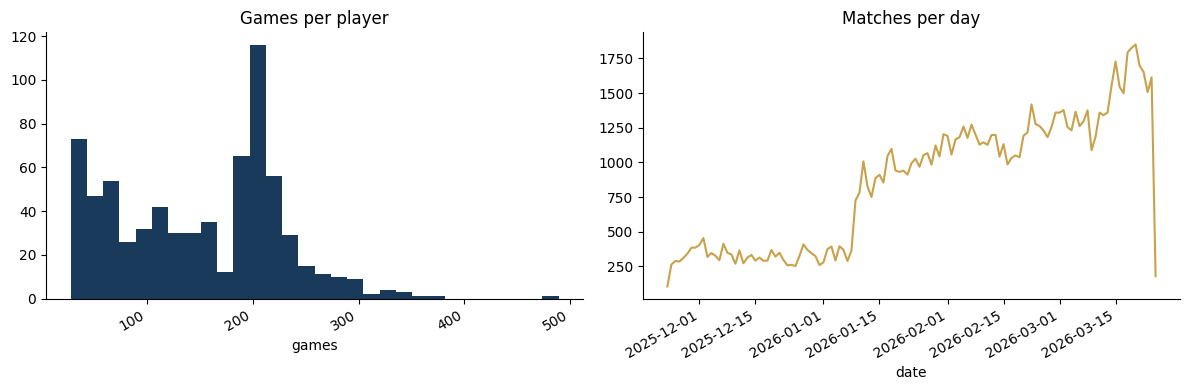

In [7]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(pp.values, bins=30, color=NAVY); ax[0].set_title("Games per player"); ax[0].set_xlabel("games")
daily = matches.groupby(matches.game_start.dt.date).size()
ax[1].plot(daily.index, daily.values, color=GOLD); ax[1].set_title("Matches per day"); ax[1].set_xlabel("date")
fig.autofmt_xdate()
for a in ax: a.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Read.** The cleaning held, every game is ranked solo and at least five minutes.
All engaged players are represented across the four month window.

**Next:** `03_feature_engineering.ipynb` collapses this to one row per player.